# Sử dụng lại bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler, MinMaxScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [3]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Bổ sung giải thích thêm

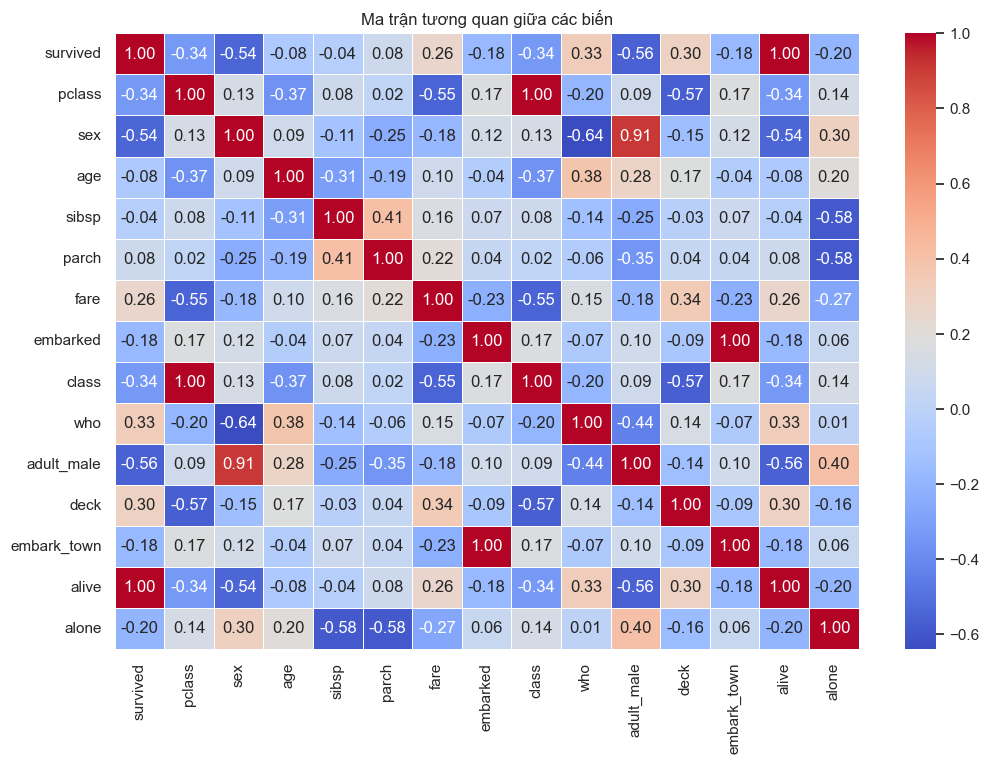

In [4]:
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# 2. Tính ma trận tương quan
corr_matrix = df_encoded.corr()

# 3. Vẽ heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Ma trận tương quan giữa các biến")
plt.show()

### Lý do loại bỏ các cột dựa trên Heatmap

1. **Cột `alive` và `survived` (Tương quan = 1.00):** 
   - **Lý do:** Gây rò rỉ dữ liệu (**Data Leakage**). Cột `alive` chính là kết quả của `survived` nhưng viết bằng chữ. Giữ lại sẽ khiến mô hình đạt accuracy ~100% bằng cách "học vẹt/gian lận", dẫn đến vô dụng trong thực tế khi gặp dữ liệu mới không có sẵn nhãn.

2. **Cột `pclass` và `class` (Tương quan = 1.00):**
   - **Lý do:** Trùng lặp thông tin hoàn toàn (1 tương đương First). Gây ra hiện tượng **Đa cộng tuyến**, làm nhiễu mô hình.

3. **Cột `sex` và `adult_male` (Tương quan rất cao):**
   - **Lý do:** Dư thừa dữ liệu vì `adult_male` được suy ra trực tiếp từ giới tính (`sex`) và tuổi (`age`).
4. **Cột `alone` (Suy ra từ `sibsp` + `parch`):**
   - **Lý do:** Đây là mối quan hệ logic ($alone = sibsp + parch == 0$). Biểu đồ Heatmap (tương quan tuyến tính) không thể giải thích hoàn hảo mối quan hệ này, nhưng về mặt bản chất, nó vẫn gây dư thừa thông tin vì biến này được phái sinh hoàn toàn từ hai biến số lượng người thân đi cùng.

**Kết luận:** Cần xóa bỏ các cột trùng lặp/rò rỉ để mô hình học từ các đặc trưng độc lập cốt lõi.


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [5]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
...

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
# leaky = [...]       điền danh sách cột cần bỏ (chỉ những cột có trong df)
# df = df.drop(columns=...)

# print("Các cột còn lại:", list(df.columns))
print("Tỷ lệ giá trị thiếu (missing value) theo từng cột:")
missing_ratios = df.isnull().mean() * 100
print(missing_ratios)

leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']

existing_leaky = [col for col in leaky if col in df.columns]

df = df.drop(columns=existing_leaky)

print("\nCác cột còn lại sau khi xử lý rò rỉ:", list(df.columns))
print("Kích thước dữ liệu mới:", df.shape)

Tỷ lệ giá trị thiếu (missing value) theo từng cột:
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

Các cột còn lại sau khi xử lý rò rỉ: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Kích thước dữ liệu mới: (891, 8)


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

### Câu trả lời: Tại sao giữ lại cột `alive` khiến mô hình đạt Accuracy ~100% nhưng vô dụng?

Việc để lại cột `alive` sẽ khiến mô hình đạt độ chính xác gần như tuyệt đối trên tập huấn luyện nhưng hoàn toàn vô dụng trong thực tế vì các lý do sau:

* **Bản chất trùng lặp (Target Duplication):** Cột `alive` (chứa giá trị `yes`/`no`) thực chất chính là biến mục tiêu `survived` (chứa giá trị `1`/`0`) nhưng được hiển thị dưới dạng chữ. 
* **Rò rỉ đáp án (Data Leakage):** Khi huấn luyện, thuật toán máy học sẽ dễ dàng phát hiện ra quy luật tuyệt đối: hễ `alive='yes'` thì `survived=1` và ngược lại. Mô hình sẽ "ăn gian" bằng cách chỉ bám vào cột `alive` để đưa ra đáp án mà bỏ qua hoàn toàn việc học các đặc trưng quan trọng khác như giới tính (`sex`), tuổi tác (`age`), hay hạng vé (`pclass`).
* **Vô dụng trong thực tế:** Mục tiêu cốt lõi của mô hình là dự đoán một hành khách mới (dữ liệu tương lai) sẽ **sống hay chết**. Tại thời điểm dự đoán đó, chúng ta hoàn toàn chưa biết kết quả, đồng nghĩa với việc cột `alive` sẽ bị bỏ trống (`NaN`) hoặc không tồn tại. Một mô hình đã bị "nghiện" phao cứu sinh `alive` từ tập train sẽ bị mất phương hướng và dự đoán sai lệch hoàn toàn khi đưa vào thực tế.

> **Kết luận:** Xóa bỏ `alive` và chỉ giữ lại một biến mục tiêu duy nhất dạng số (`survived`) là bắt buộc để mô hình thực sự học được các quy luật khách quan từ dữ liệu.


---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [6]:
# TODO 2: shape, info, describe
# 1. In số dòng và số cột
print(f"Kích thước dữ liệu: {df.shape[0]} dòng và {df.shape[1]} cột.")
print(f"Biến mục tiêu (Target) là: 'survived' (1: sống, 0: không may mắn).")
print("-" * 50)

# 2. Xem kiểu dữ liệu và giá trị non-null
print("Thông tin tổng quan về dữ liệu:")
df.info()
print("-" * 50)

# 3. Thống kê cơ bản
print("Thống kê mô tả cho các biến số:")
display(df.describe())

print("\nThống kê mô tả cho các biến phân loại (Categorical):")
# Bao gồm cả kiểu object và category (kiểu dữ liệu đặc thù của pandas)
display(df.describe(include=['object', 'category']))

Kích thước dữ liệu: 891 dòng và 8 cột.
Biến mục tiêu (Target) là: 'survived' (1: sống, 0: không may mắn).
--------------------------------------------------
Thông tin tổng quan về dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
--------------------------------------------------
Thống kê mô tả cho các biến số:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Thống kê mô tả cho các biến phân loại (Categorical):


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

*(viết tại đây...)*
### Dựa trên kết quả quan sát, các cột dữ liệu được phân loại như sau:

### 1. Biến số (Numerical)
*Đây là các cột chứa giá trị đo lường, có thể thực hiện các phép toán cộng, trừ, tính trung bình.*
* **`age`**: Tuổi của hành khách.
* **`fare`**: Giá vé hành khách đã trả.
* **`sibsp`**: Số lượng anh chị em hoặc vợ/chồng đi cùng.
* **`parch`**: Số lượng cha mẹ hoặc con cái đi cùng.

### 2. Biến phân loại (Categorical)
*Đây là các cột chứa nhãn hoặc nhóm dữ liệu.*
* **`survived`**: Biến mục tiêu (0 hoặc 1). Dù ở dạng số nhưng bản chất là nhãn Phân loại.
* **`pclass`**: Hạng vé (1, 2, 3). Đây là biến phân loại có thứ tự (Ordinal).
* **`sex`**: Giới tính (`male`, `female`).
* **`embarked`**: Cảng lên tàu (`C`, `Q`, `S`).
> **Khác biệt bảng số liệu:** Mặc dù `survived` và `pclass` có bản chất là biến phân loại, nhưng do dữ liệu gốc đang lưu chúng ở dạng số nguyên (`int64`), hàm `df.describe()` mặc định của Pandas đã xếp chúng vào bảng thống kê biến số. 



---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [7]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()

# Tính tỷ lệ phần trăm thiếu
missing_percent = (df.isnull().sum() / len(df)) * 100

# Tổng hợp vào một DataFrame để dễ quan sát
missing_summary = pd.DataFrame({
    'Số lượng thiếu': missing_count,
    'Tỷ lệ (%)': missing_percent
})

# Chỉ lọc ra các cột có giá trị thiếu > 0
missing_summary = missing_summary[missing_summary['Số lượng thiếu'] > 0]

print("Bảng thống kê các cột thiếu dữ liệu:")
display(missing_summary)

Bảng thống kê các cột thiếu dữ liệu:


,Số lượng thiếu,Tỷ lệ (%)
age,177,19.865320
embarked,2,0.224467


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
| :--- | :--- | :--- | :--- |
| **`age`** | ~19.87% | Điền Median (Trung vị) | Cột tuổi có một số giá trị ngoại lệ (người cao tuổi). Median bền vững hơn Mean, giúp tránh việc các giá trị ngoại lệ làm lệch dữ liệu "trung tâm". |
| **`embarked`** | ~0.22% | Điền Mode (Yếu vị) | Đây là biến phân loại (Categorical). Vì chỉ thiếu 2 mẫu (tỷ lệ cực thấp), việc điền bằng giá trị xuất hiện nhiều nhất (thường là cảng 'S') là cách đơn giản và hiệu quả nhất. |


---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [8]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
        # trả về số lượng outlier theo IQR
    s_clean = s.dropna()
    Q1 = s_clean.quantile(0.25)
    Q3 = s_clean.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = s_clean[(s_clean < lower_bound) | (s_clean > upper_bound)]
    return len(outliers)

def dem_outlier_zscore(s, nguong=3.0):
        # trả về số lượng outlier theo Z-score
    s_clean = s.dropna()
    # Tính giá trị tuyệt đối của z-score
    z_scores = np.abs(stats.zscore(s_clean))
    outliers = s_clean[z_scores > nguong]
    return len(outliers)

# for col in ["age", "fare"]:
#     ...
for col in ["age", "fare"]:
    print(f"Cột [{col}]:")
    print(f"  - Số outlier (IQR): {dem_outlier_iqr(df[col])}")
    print(f"  - Số outlier (Z-score): {dem_outlier_zscore(df[col])}")
    print("-" * 30)

Cột [age]:
  - Số outlier (IQR): 11
  - Số outlier (Z-score): 2
------------------------------
Cột [fare]:
  - Số outlier (IQR): 116
  - Số outlier (Z-score): 20
------------------------------


**Trả lời 4 (quyết định với outlier của `fare`):**

**Quyết định:** Giữ lại toàn bộ các giá trị ngoại lai của cột `fare` (Giá vé), không loại bỏ.

**Lý do giải thích:**
1. **Hiện tượng thực tế, không phải lỗi nhập liệu:** Tàu Titanic có sự phân hóa giai cấp rất rõ rệt. Những hành khách thuộc khoang Hạng Nhất (First Class) hoặc phòng Thượng hạng (Suite) phải trả mức giá vé cực kỳ cao (lên tới hơn 512$) so với mức giá trung bình của hành khách Hạng Ba (chỉ khoảng 7$ - 8$). Do đó, các giá vé đắt bất thường này phản ánh đúng thực tế lịch sử.
2. **Biến số mang thông tin sống còn:** Giá vé cao tỷ lệ thuận với vị trí phòng ở tầng trên, gần boong cứu hộ, giúp họ có cơ hội sống sót cao hơn. Nếu loại bỏ các outlier này, mô hình sẽ mất đi thông tin cực kỳ quan trọng để dự đoán nhóm người giàu có khả năng sống sót cao.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

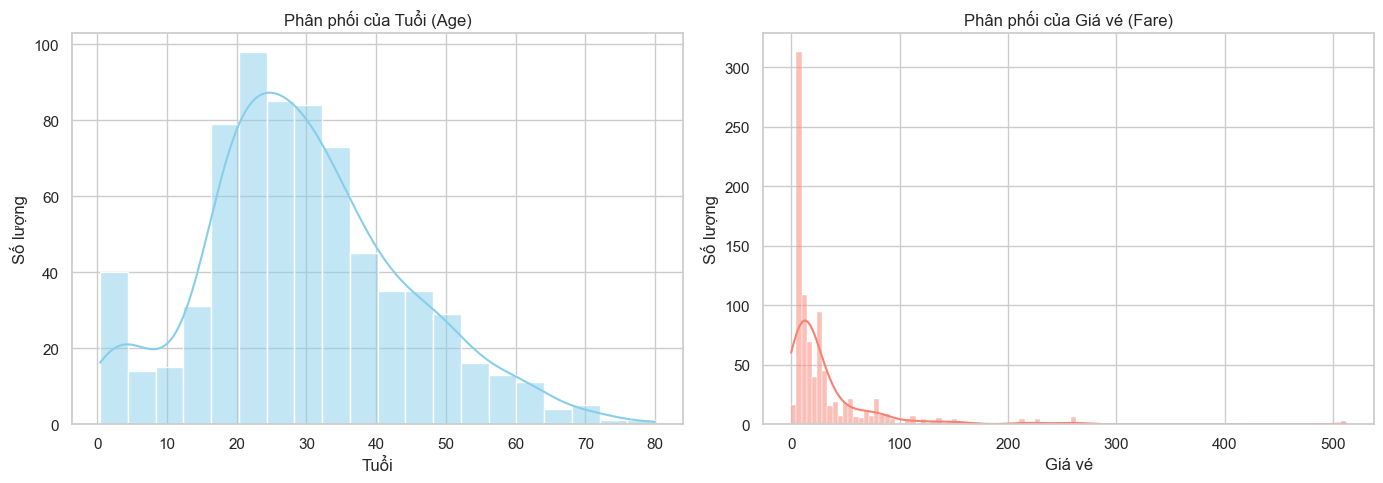

In [9]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vẽ histogram cho biến age
sns.histplot(data=df, x="age", kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Phân phối của Tuổi (Age)")
axes[0].set_xlabel("Tuổi")
axes[0].set_ylabel("Số lượng")

# Vẽ histogram cho biến fare
sns.histplot(data=df, x="fare", kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Phân phối của Giá vé (Fare)")
axes[1].set_xlabel("Giá vé")
axes[1].set_ylabel("Số lượng")

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14900\401039936.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="pclass", y="fare", palette="Set2")


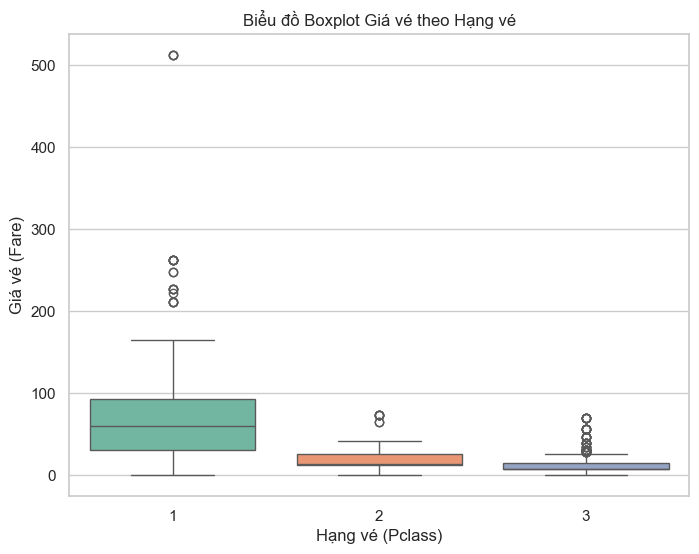

In [10]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize=(8, 6))

# Vẽ boxplot của giá vé (fare) theo từng nhóm hạng vé (pclass)
sns.boxplot(data=df, x="pclass", y="fare", palette="Set2")

plt.title("Biểu đồ Boxplot Giá vé theo Hạng vé")
plt.xlabel("Hạng vé (Pclass)")
plt.ylabel("Giá vé (Fare)")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14900\2145494768.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="sex", y="survived", ax=axes[0], palette="pastel", errorbar=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_14900\2145494768.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="pclass", y="survived", ax=axes[1], palette="muted", errorbar=None)


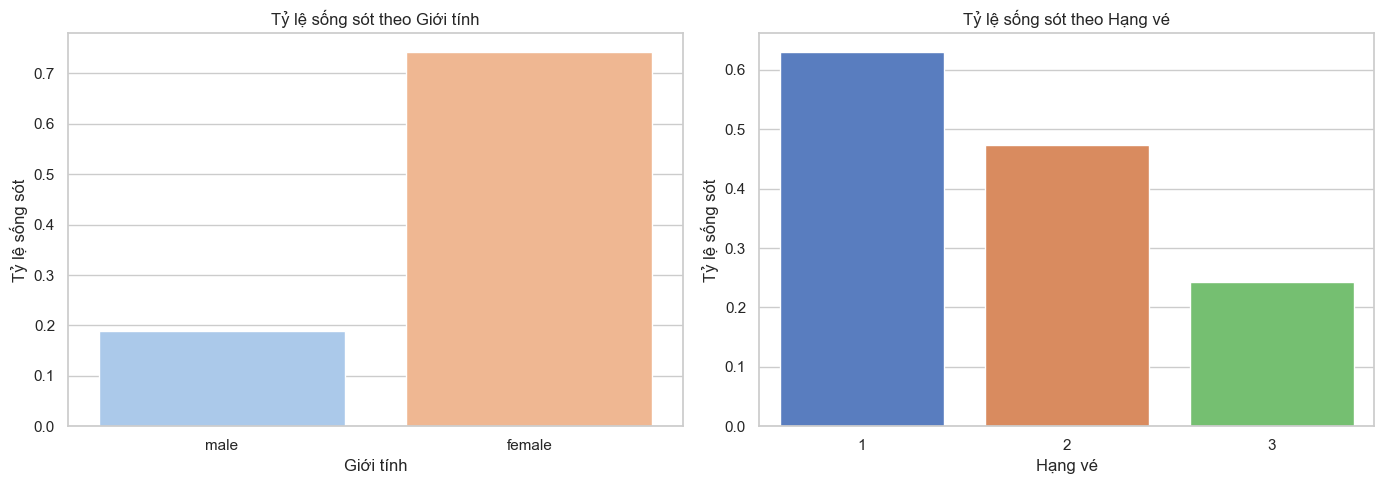

In [11]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vẽ tỷ lệ sống sót theo giới tính (sex)
sns.barplot(data=df, x="sex", y="survived", ax=axes[0], palette="pastel", errorbar=None)
axes[0].set_title("Tỷ lệ sống sót theo Giới tính")
axes[0].set_xlabel("Giới tính")
axes[0].set_ylabel("Tỷ lệ sống sót")

# Vẽ tỷ lệ sống sót theo hạng vé (pclass)
sns.barplot(data=df, x="pclass", y="survived", ax=axes[1], palette="muted", errorbar=None)
axes[1].set_title("Tỷ lệ sống sót theo Hạng vé")
axes[1].set_xlabel("Hạng vé")
axes[1].set_ylabel("Tỷ lệ sống sót")

plt.tight_layout()
plt.show()

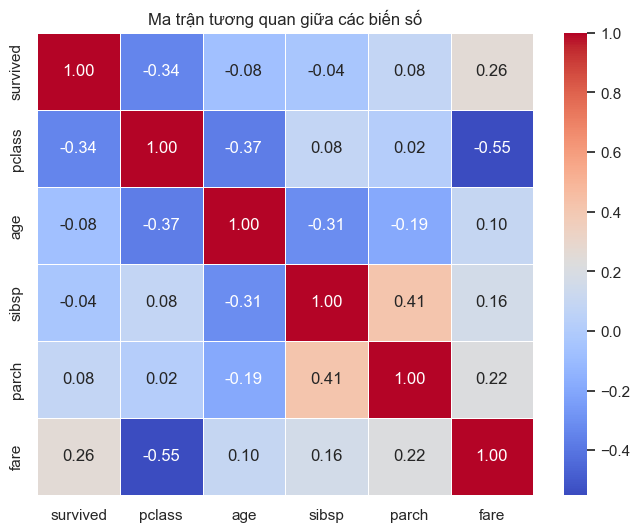

In [12]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(8, 6))

# Lọc các biến số còn lại sau khi xử lý rò rỉ dữ liệu để tính tương quan
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

# Vẽ bản đồ nhiệt thể hiện ma trận tương quan
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Ma trận tương quan giữa các biến số")
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**


- **Histogram:** Phân phối của biến `age` có dạng hình chuông gần như chuẩn nhưng hơi **lệch phải (skewed right)** nhẹ, tập trung đông nhất ở nhóm thanh niên từ 20-40 tuổi. Trái lại, phân phối của `fare` bị **lệch phải cực kỳ nặng**, phần lớn hành khách mua vé giá rẻ dưới 50$ và chỉ có số ít mua vé đắt kéo dài đồ thị về bên phải.

- **Boxplot:** Giá vé có sự phân hóa rất rõ ràng giữa các nhóm, trong đó trung vị giá vé của Hạng 1 cao vượt trội so với Hạng 2 và Hạng 3. Đồng thời, cả 3 hạng vé đều xuất hiện rất nhiều **outlier (giá trị ngoại lai)**, đặc biệt là các tấm vé siêu đắt ở Hạng 1 (lên tới hơn 512$).

- **Bar survival:** Nữ giới có tỷ lệ sống sót cao vượt trội (~74%) so với nam giới (~19%), chênh lệch nhau khoảng 55%. Xét theo hạng vé, hành khách Hạng 1 có tỷ lệ sống sót cao nhất (~63%), tiếp đến là Hạng 2 (~47%) và thấp nhất là Hạng 3 (~24%).

- **Heatmap:** Cặp biến số có mối tương quan mạnh nhất là **`fare` và `pclass`** với hệ số tương quan âm khoảng `-0.55`, cho thấy hạng vé càng cao cấp (số pclass càng nhỏ) thì giá vé càng đắt. Biến mục tiêu `survived` có xu hướng tương quan thuận với `fare` và tương quan nghịch với `pclass`.


---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [13]:
# TODO 6: chia train/val/test có stratify

# X_tmp, X_test, y_tmp, y_test = train_test_split(...)
# X_train, X_val, y_train, y_val = train_test_split(...)

# print("Train/Val/Test:", ...)
# in tỷ lệ survived từng tập

# 1. Tách X (đặc trưng) và y (biến mục tiêu)
X = df.drop(columns=['survived'])
y = df['survived']


X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)


X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.1765, random_state=42, stratify=y_tmp
)

# 4. In kết quả kiểm tra
print(f"Kích thước tập Train: {X_train.shape} - Chiếm {(len(X_train)/len(df)):.1%}")
print(f"Kích thước tập Val:   {X_val.shape} - Chiếm {(len(X_val)/len(df)):.1%}")
print(f"Kích thước tập Test:  {X_test.shape} - Chiếm {(len(X_test)/len(df)):.1%}")

print("-" * 30)
print("Kiểm tra tỷ lệ sống sót (Class Balance):")
print(f"Tỷ lệ trên tập Train: {y_train.mean():.2%}")
print(f"Tỷ lệ trên tập Val:   {y_val.mean():.2%}")
print(f"Tỷ lệ trên tập Test:  {y_test.mean():.2%}")


Kích thước tập Train: (623, 7) - Chiếm 69.9%
Kích thước tập Val:   (134, 7) - Chiếm 15.0%
Kích thước tập Test:  (134, 7) - Chiếm 15.0%
------------------------------
Kiểm tra tỷ lệ sống sót (Class Balance):
Tỷ lệ trên tập Train: 38.36%
Tỷ lệ trên tập Val:   38.81%
Tỷ lệ trên tập Test:  38.06%


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [14]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy='most_frequent')), # Điền giá trị xuất hiện nhiều nhất
    ("onehot", OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # Chuyển chữ thành số
])

preprocess = ColumnTransformer([
    ("num", pipe_so, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols), # Giữ nguyên pclass
])


# preprocess.fit(X_train)               # fit CHỈ trên train
# X_train_t = preprocess.transform(X_train)
# ... transform cho val, test
# print(X_train_t.shape, list(preprocess.get_feature_names_out()))
X_train_pre = preprocess.fit_transform(X_train)
X_val_pre = preprocess.transform(X_val)
X_test_pre = preprocess.transform(X_test)

print(f"Kích thước X_train sau biến đổi: {X_train_pre.shape}")
print("Tên các cột mới sau khi xử lý:")
print(preprocess.get_feature_names_out())

Kích thước X_train sau biến đổi: (623, 10)
Tên các cột mới sau khi xử lý:
['num__age' 'num__sibsp' 'num__parch' 'num__fare' 'cat__sex_female'
 'cat__sex_male' 'cat__embarked_C' 'cat__embarked_Q' 'cat__embarked_S'
 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Việc `fit` các bộ tiền xử lý (như tính toán trung vị hay thang đo) chỉ trên tập **Train** giúp tránh **Rò rỉ dữ liệu (Data Leakage)** vì các lý do cốt lõi sau:

* **Giữ cho tập Test luôn "mới":** 
  * Trong thực tế, dữ liệu Test (hoặc dữ liệu từ khách hàng sau này) là những thứ chưa tồn tại lúc ta huấn luyện mô hình. 
  * Nếu ta tính trung vị (`Median`) trên toàn bộ bảng dữ liệu (gộp cả Train và Test), thông tin về xu hướng phân phối của tập Test đã vô tình lọt vào con số trung vị đó.
* **Đánh giá khách quan:** 
  * Khi mô hình chạy trên tập Test, nó đang xử lý dữ liệu hoàn toàn dựa trên "kinh nghiệm" đã học từ tập Train. 
  * Nếu ta dùng thông tin của tập Test để chuẩn hóa, kết quả đánh giá sẽ bị "ảo" (quá tốt so với thực tế) vì mô hình đã được hỗ trợ bởi các thông số thống kê của chính tập dữ liệu mà nó đang phải dự đoán.


---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [15]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
class_counts = df['survived'].value_counts()
class_ratios = df['survived'].value_counts(normalize=True) * 100

print("Thống kê biến mục tiêu 'survived':")
print(f" - Số người không sống sót (0): {class_counts[0]} ({class_ratios[0]:.2f}%)")
print(f" - Số người sống sót (1):      {class_counts[1]} ({class_ratios[1]:.2f}%)")

Thống kê biến mục tiêu 'survived':
 - Số người không sống sót (0): 549 (61.62%)
 - Số người sống sót (1):      342 (38.38%)


### Trả lời 8: 

#### 1. Đánh giá độ mất cân bằng của biến mục tiêu
* **Thực tế dữ liệu:** Biến `survived` có sự mất cân bằng nhẹ (khoảng **62% lớp 0** và **38% lớp 1**). 
* **Nhận xét:** Mặc dù tỷ lệ này không quá cực đoan như các bài toán phát hiện lừa đảo (thường là 99% vs 1%), nhưng sự chênh lệch này vẫn đủ lớn để gây sai lệch nếu chỉ nhìn vào các chỉ số thông thường. Do đó, chúng ta bắt buộc phải cân nhắc kỹ lưỡng khi lựa chọn thước đo đánh giá mô hình.

#### 2. Trường hợp chỉ số Accuracy (Độ chính xác tổng thể) bị đánh lừa
* **Cơ chế:** `Accuracy` sẽ bị đánh lừa khi mô hình chỉ cần "đoán mò" theo số đông mà không cần học bất kỳ quy luật nào.
* **Ví dụ minh họa:** Nếu một mô hình cực kỳ đơn giản (hoặc lười biếng) luôn dự đoán rằng *"Tất cả mọi người đều không sống sót"* (luôn trả về nhãn `0`), nó vẫn nghiễm nhiên đạt được mức `Accuracy` là **~62%**. Con số 62% nghe có vẻ ổn trên bề nổi, nhưng thực tế mô hình này hoàn toàn vô dụng vì nó không tìm ra được bất kỳ người sống sót nào (chỉ số `Recall` cho lớp 1 bằng đúng `0`).

#### 3. Metric ưu tiên cho bài toán Titanic và lý do
* **Metric ưu tiên:** **F1-Score**
* **Lý do lựa chọn:** 
  * F1-Score là giá trị trung bình điều hòa giữa `Precision` (độ tin cậy khi dự đoán sống) và `Recall` (khả năng tìm hết những người sống sót).
  * Trong bài toán cứu hộ Titanic, chúng ta đòi hỏi mô hình vừa phải tìm được nhiều người sống sót nhất có thể (`Recall` cao), vừa phải đảm bảo những người mà nó dự đoán là "sống" thực sự có cơ hội sống sót cao (`Precision` cao). 
  * **F1-Score** giúp cân bằng chặt chẽ cả hai yếu tố mâu thuẫn này, giúp người phân tích không bị đánh lừa bởi sự mất cân bằng dữ liệu giống như chỉ số `Accuracy`.


---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

### Nhận xét tổng hợp về dữ liệu hành khách Titanic (Task 9)

1. **Đặc trưng tương quan mạnh nhất với khả năng sống sót:** 
   - **Bằng chứng:** Biểu đồ Barplot cho thấy **Giới tính (`sex`)** có ảnh hưởng lớn nhất. Tỷ lệ sống sót của Nữ giới lên tới ~74%, trong khi Nam giới chỉ đạt ~19% (chênh lệch ~55%). Kế đến là **Hạng vé (`pclass`)** với hệ số tương quan âm mạnh trên Heatmap (~ -0.34), chứng minh người đi Hạng 1 có cơ hội sống cao nhất (~63%) và giảm dần xuống Hạng 3 (~24%).

2. **Cột thiếu dữ liệu nhiều nhất và cách xử lý:** 
   - **Bằng chứng:** Cột **`age` (Tuổi)** thiếu dữ liệu nhiều nhất trong các biến giữ lại, với 177 giá trị trống (chiếm ~19.87% tổng số dòng). Cột **`embarked`** thiếu ít hơn với 2 dòng (~0.22%). Trong Pipeline tiền xử lý, ta sử dụng giải pháp an toàn: điền khuyết bằng số trung vị (`SimpleImputer(strategy='median')`) cho cột số `age` để tránh nhiễu do outlier, và điền khuyết bằng giá trị xuất hiện nhiều nhất (`strategy='most_frequent'`) cho cột chữ `embarked`.

3. **Mức độ mất cân bằng của biến mục tiêu:** 
   - **Bằng chứng:** Thống kê mô tả (`describe`) cho thấy tỷ lệ sống sót trung bình chỉ đạt **38.38%** (342 người sống sót trên tổng số 891 hành khách). Sự mất cân bằng này ở mức nhẹ-vừa (tỷ lệ ~6:4). Hệ quả là khi đánh giá mô hình, ta không nên tin tưởng tuyệt đối vào số điểm **Accuracy (Độ chính xác tổng thể)** mà cần ưu tiên sử dụng thêm các chỉ số như **F1-score**, **Precision**, **Recall** hoặc đường cong **ROC-AUC** để phản ánh đúng khả năng dự đoán chính xác trên từng nhóm sống/chết độc lập.

4. **Các đặc trưng cần thực hiện Scaling và Encoding:** 
   - **Bằng chứng:** 
     - **Scaling (Chuẩn hóa):** Cần áp dụng cho nhóm biến số (`age`, `sibsp`, `parch`, `fare`), đặc biệt là `fare` vì có biên độ giá trị quá rộng (0$ đến 512$) và chứa cực kỳ nhiều outlier đắt đỏ. Ta sử dụng `RobustScaler` (dựa trên Median và IQR) để đưa các cột này về cùng thang đo mà không bị ảnh hưởng xấu bởi hành khách siêu giàu.
     - **Encoding (Mã hóa):** Cần áp dụng cho nhóm biến chữ (`sex`, `embarked`). Ta sử dụng `OneHotEncoder` để phân rã cột chữ thành các ma trận số nhị phân `0.0` và `1.0` độc lập (ví dụ từ 2 cột giới tính ban đầu sinh ra 10 cột số hoàn chỉnh ở đầu ra Pipeline) giúp thuật toán học máy đọc hiểu được. Biến `pclass` được giữ nguyên (`passthrough`) vì bản chất là số có thứ tự logic 1 < 2 < 3.

5. **Một điều thú vị và bất ngờ phát hiện từ dữ liệu:** 
   - **Bằng chứng:** Dù nam giới chiếm đa số trên tàu (577 người so với 314 nữ), tỷ lệ sống sót của họ lại thấp đến mức kinh ngạc (chỉ ~19% so với ~74% của nữ). Sự chênh lệch khổng lồ này (~55%) chứng minh quy tắc đạo đức "Ưu tiên phụ nữ và trẻ em" trong lịch sử hàng hải đã được thực thi cực kỳ nghiêm túc vào thời khắc sinh tử, bất chấp sự phân hóa giàu nghèo hay địa vị xã hội.


## BỔ SUNG THÊM PHẦN DỰ ĐOÁN CHO BÀI TẬP BUỔI 7
# Phần Logistic regression 

In [19]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
log_reg = LogisticRegression(max_iter=1000)
lin_reg = LinearRegression()

# 2. Huấn luyện mô hình với dữ liệu Train
log_reg.fit(X_train_pre, y_train)
lin_reg.fit(X_train_pre, y_train)

# 3. Dự đoán kết quả trên tập Test
y_pred_log = log_reg.predict(X_test_pre)

# nếu >= 0.5 là 1 (Sống), dưới 0.5 là 0 (Chết)
y_pred_lin_raw = lin_reg.predict(X_test_pre)
y_pred_lin = np.where(y_pred_lin_raw >= 0.5, 1, 0)

# 4. Hàm in báo cáo kết quả
def in_ket_qua(ten_mo_hinh, y_true, y_pred):
    print(f"=== KẾT QUẢ: {ten_mo_hinh} ===")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("-" * 40)

# 5. Xuất kết quả so sánh
in_ket_qua("Logistic Regression", y_test, y_pred_log)
in_ket_qua("Linear Regression (Ngưỡng 0.5)", y_test, y_pred_lin)

=== KẾT QUẢ: Logistic Regression ===
Accuracy:  0.7761
Precision: 0.7442
Recall:    0.6275
F1-score:  0.6809
Confusion Matrix:
 [[72 11]
 [19 32]]
----------------------------------------
=== KẾT QUẢ: Linear Regression (Ngưỡng 0.5) ===
Accuracy:  0.7612
Precision: 0.7021
Recall:    0.6471
F1-score:  0.6735
Confusion Matrix:
 [[69 14]
 [18 33]]
----------------------------------------


### Đánh giá và So sánh Hiệu suất Mô hình (Titanic Dataset)

Dựa trên kết quả thực nghiệm với cùng một mức ngưỡng phân loại nhị phân là `0.5`, dưới đây là phân tích định lượng về hiệu suất giữa hai mô hình:

#### 1. Bảng số liệu đối chiếu thực nghiệm

| Chỉ số đánh giá | Logistic Regression | Linear Regression (Ngưỡng 0.5) | Chênh lệch (Logistic - Linear) |
| :--- | :---: | :---: | :---: |
| **Accuracy** (Độ chính xác) | 0.7761 | 0.7612 | +0.0149 |
| **Precision** (Độ chuẩn xác) | 0.7442 | 0.7021 | +0.0421 |
| **Recall** (Độ bao phủ) | 0.6275 | 0.6471 | -0.0196 |
| **F1-score** (Điểm F1) | 0.6809 | 0.6735 | +0.0074 |

#### 2. Phân tích bằng chứng số liệu và Bản chất toán học

*   **Tính vượt trội của Logistic Regression:** Mô hình Logistic Regression đạt hiệu suất tổng thể tốt hơn với **Accuracy là 0.7761** và **F1-score là 0.6809**. Điểm nhấn lớn nhất là chỉ số Precision đạt **0.7442** (cao hơn Linear Regression 4.21%), thể hiện qua ma trận nhầm lẫn khi chỉ đoán sai 11 ca hành khách chết thành sống (so với 14 ca của Linear Regression). Về mặt toán học, hàm kích hoạt *Sigmoid* đã ép đầu ra về khoảng xác suất $$, giúp thiết lập ranh giới phân tách (Decision Boundary) tối ưu hơn cho bài toán phân loại nhị phân này.
*   **Hạn chế của Linear Regression:** Dù Linear Regression có điểm Recall nhỉnh hơn một chút (**0.6471** so với 0.6275, cứu thêm được 1 người sống), nhưng lại đánh đổi bằng độ chuẩn xác thấp hơn rõ rệt (Precision giảm xuống còn 0.7021). Do bản chất là thuật toán tìm đường thẳng để dự đoán giá trị liên tục, việc cố định một mức ngưỡng cứng `0.5` khiến mô hình nhạy cảm với các biến ngoại lai (Outliers), làm giảm khả năng phân loại chính xác tổng thể (F1-score chỉ đạt **0.6735**).

**Kết luận:** Số liệu thực nghiệm khẳng định **Logistic Regression** là lựa chọn phù hợp và ổn định hơn cho bài toán phân loại hành khách Titanic. Điểm F1-score ở mức 0.6809 của Logistic Regression đạt mức khá, phản ánh đúng bản chất dữ liệu học tập và không bị hiện tượng học vẹt (Overfitting).
